In [1]:
import scanpy as sc
tcell=sc.read_h5ad('/nfs/team361/vm11/ivlps/data/tcell_raw_matrix_annotated.h5ad')

In [2]:
tcell

AnnData object with n_obs × n_vars = 69370 × 35976
    obs: 'patient_id', 'time_after_LPS', 'Sex', 'age', 'batch', 'IR_VJ_1_locus_tcr', 'IR_VJ_2_locus_tcr', 'IR_VDJ_1_locus_tcr', 'IR_VDJ_2_locus_tcr', 'IR_VJ_1_cdr3_tcr', 'IR_VJ_2_cdr3_tcr', 'IR_VDJ_1_cdr3_tcr', 'IR_VDJ_2_cdr3_tcr', 'IR_VJ_1_cdr3_nt_tcr', 'IR_VJ_2_cdr3_nt_tcr', 'IR_VDJ_1_cdr3_nt_tcr', 'IR_VDJ_2_cdr3_nt_tcr', 'IR_VJ_1_expr_tcr', 'IR_VJ_2_expr_tcr', 'IR_VDJ_1_expr_tcr', 'IR_VDJ_2_expr_tcr', 'IR_VJ_1_expr_raw_tcr', 'IR_VJ_2_expr_raw_tcr', 'IR_VDJ_1_expr_raw_tcr', 'IR_VDJ_2_expr_raw_tcr', 'IR_VJ_1_v_gene_tcr', 'IR_VJ_2_v_gene_tcr', 'IR_VDJ_1_v_gene_tcr', 'IR_VDJ_2_v_gene_tcr', 'IR_VJ_1_d_gene_tcr', 'IR_VJ_2_d_gene_tcr', 'IR_VDJ_1_d_gene_tcr', 'IR_VDJ_2_d_gene_tcr', 'IR_VJ_1_j_gene_tcr', 'IR_VJ_2_j_gene_tcr', 'IR_VDJ_1_j_gene_tcr', 'IR_VDJ_2_j_gene_tcr', 'IR_VJ_1_c_gene_tcr', 'IR_VJ_2_c_gene_tcr', 'IR_VDJ_1_c_gene_tcr', 'IR_VDJ_2_c_gene_tcr', 'IR_VJ_1_junction_ins_tcr', 'IR_VJ_2_junction_ins_tcr', 'IR_VDJ_1_junction_ins_tcr'

In [3]:
bcell=sc.read_h5ad('/nfs/team361/vm11/ivlps/data/bcell_raw_matrix_annotated_allanno.h5ad')

In [4]:
bcell

AnnData object with n_obs × n_vars = 11964 × 36601
    obs: 'patient_id', 'time_after_LPS', 'Sex', 'age', 'batch', 'IR_VJ_1_locus_tcr', 'IR_VJ_2_locus_tcr', 'IR_VDJ_1_locus_tcr', 'IR_VDJ_2_locus_tcr', 'IR_VJ_1_cdr3_tcr', 'IR_VJ_2_cdr3_tcr', 'IR_VDJ_1_cdr3_tcr', 'IR_VDJ_2_cdr3_tcr', 'IR_VJ_1_cdr3_nt_tcr', 'IR_VJ_2_cdr3_nt_tcr', 'IR_VDJ_1_cdr3_nt_tcr', 'IR_VDJ_2_cdr3_nt_tcr', 'IR_VJ_1_expr_tcr', 'IR_VJ_2_expr_tcr', 'IR_VDJ_1_expr_tcr', 'IR_VDJ_2_expr_tcr', 'IR_VJ_1_expr_raw_tcr', 'IR_VJ_2_expr_raw_tcr', 'IR_VDJ_1_expr_raw_tcr', 'IR_VDJ_2_expr_raw_tcr', 'IR_VJ_1_v_gene_tcr', 'IR_VJ_2_v_gene_tcr', 'IR_VDJ_1_v_gene_tcr', 'IR_VDJ_2_v_gene_tcr', 'IR_VJ_1_d_gene_tcr', 'IR_VJ_2_d_gene_tcr', 'IR_VDJ_1_d_gene_tcr', 'IR_VDJ_2_d_gene_tcr', 'IR_VJ_1_j_gene_tcr', 'IR_VJ_2_j_gene_tcr', 'IR_VDJ_1_j_gene_tcr', 'IR_VDJ_2_j_gene_tcr', 'IR_VJ_1_c_gene_tcr', 'IR_VJ_2_c_gene_tcr', 'IR_VDJ_1_c_gene_tcr', 'IR_VDJ_2_c_gene_tcr', 'IR_VJ_1_junction_ins_tcr', 'IR_VJ_2_junction_ins_tcr', 'IR_VDJ_1_junction_ins_tcr'

In [5]:
myeloid=sc.read_h5ad('/nfs/team361/vm11/ivlps/data/mcell_raw_matrix_annotated.h5ad')

In [6]:
myeloid.X.max()

np.float32(1936.0)

In [7]:
combined_data=tcell.concatenate(bcell,myeloid)

/tmp/ipykernel_3726396/3716584077.py:1: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  combined_data=tcell.concatenate(bcell,myeloid)


In [ ]:
combined_data.write_h5ad('./private_lps_data.h5ad')

In [9]:
# mitochondrial genes
combined_data.var["mt"] = combined_data.var_names.str.startswith("MT-")
# ribosomal genes
combined_data.var["ribo"] = combined_data.var_names.str.startswith(("RPS", "RPL"))
# hemoglobin genes.
combined_data.var["hb"] = combined_data.var_names.str.contains(("^HB[^(P)]"))

In [10]:
sc.pp.calculate_qc_metrics(
    combined_data, qc_vars=["mt", "ribo", "hb"], inplace=True, percent_top=[20], log1p=True
)
combined_data

AnnData object with n_obs × n_vars = 122263 × 35976
    obs: 'patient_id', 'time_after_LPS', 'Sex', 'age', 'batch', 'IR_VJ_1_locus_tcr', 'IR_VJ_2_locus_tcr', 'IR_VDJ_1_locus_tcr', 'IR_VDJ_2_locus_tcr', 'IR_VJ_1_cdr3_tcr', 'IR_VJ_2_cdr3_tcr', 'IR_VDJ_1_cdr3_tcr', 'IR_VDJ_2_cdr3_tcr', 'IR_VJ_1_cdr3_nt_tcr', 'IR_VJ_2_cdr3_nt_tcr', 'IR_VDJ_1_cdr3_nt_tcr', 'IR_VDJ_2_cdr3_nt_tcr', 'IR_VJ_1_expr_tcr', 'IR_VJ_2_expr_tcr', 'IR_VDJ_1_expr_tcr', 'IR_VDJ_2_expr_tcr', 'IR_VJ_1_expr_raw_tcr', 'IR_VJ_2_expr_raw_tcr', 'IR_VDJ_1_expr_raw_tcr', 'IR_VDJ_2_expr_raw_tcr', 'IR_VJ_1_v_gene_tcr', 'IR_VJ_2_v_gene_tcr', 'IR_VDJ_1_v_gene_tcr', 'IR_VDJ_2_v_gene_tcr', 'IR_VJ_1_d_gene_tcr', 'IR_VJ_2_d_gene_tcr', 'IR_VDJ_1_d_gene_tcr', 'IR_VDJ_2_d_gene_tcr', 'IR_VJ_1_j_gene_tcr', 'IR_VJ_2_j_gene_tcr', 'IR_VDJ_1_j_gene_tcr', 'IR_VDJ_2_j_gene_tcr', 'IR_VJ_1_c_gene_tcr', 'IR_VJ_2_c_gene_tcr', 'IR_VDJ_1_c_gene_tcr', 'IR_VDJ_2_c_gene_tcr', 'IR_VJ_1_junction_ins_tcr', 'IR_VJ_2_junction_ins_tcr', 'IR_VDJ_1_junction_ins_tcr

In [11]:
import seaborn as sns

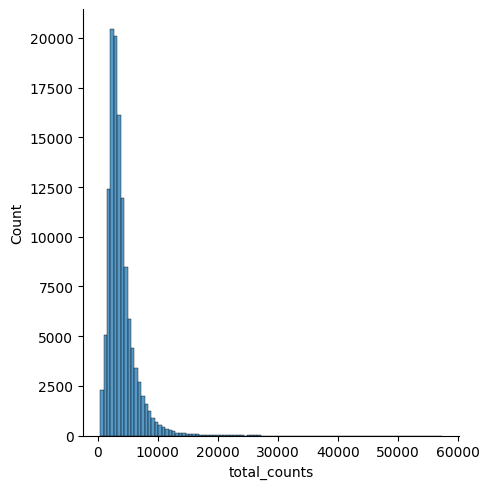

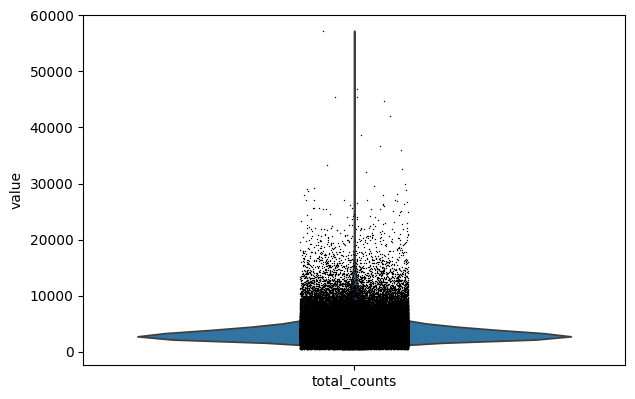

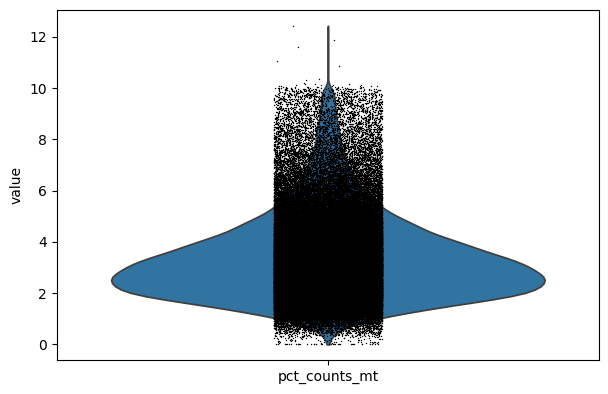

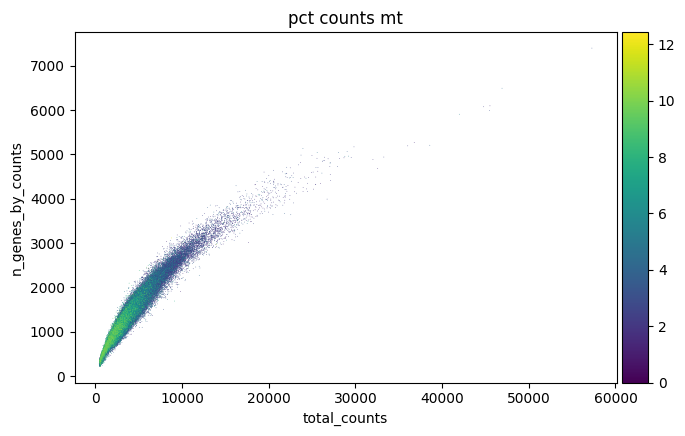

In [12]:
p1 = sns.displot(combined_data.obs["total_counts"], bins=100, kde=False)
sc.pl.violin(combined_data, 'total_counts')
p2 = sc.pl.violin(combined_data, "pct_counts_mt")
p3 = sc.pl.scatter(combined_data, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

In [13]:
combined_data = combined_data[combined_data.obs['pct_counts_mt'] <= 8]

In [14]:
sc.pp.filter_cells(combined_data, max_counts=150000)

/software/cellgen/team361/am74/envs/pertpy/lib/python3.9/site-packages/scanpy/preprocessing/_simple.py:165: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs["n_counts"] = number


/tmp/ipykernel_968620/3987137127.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(combined_data.obs['n_genes'], kde=False, bins=60)


<Axes: xlabel='n_genes'>

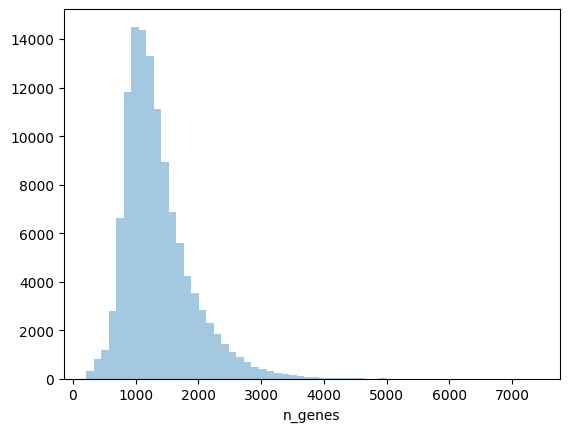

In [15]:
combined_data.obs['n_genes'] = (combined_data.X > 0).sum(1)
sns.distplot(combined_data.obs['n_genes'], kde=False, bins=60)

In [16]:
sc.pp.filter_genes(combined_data, min_cells=20)
print('Number of genes after cell filter: {:d}'.format(combined_data.n_vars))

Number of genes after cell filter: 19186


In [17]:
# Assuming `adata` is your AnnData object
combined_data.obs['batch'] = combined_data.obs['batch'].cat.rename_categories({
    '0': 'T cell lineage',
    '1': 'B cell lineage',
    '2': 'Myeloid lineage'
})

In [18]:
combined_data.obs['final_anno'].value_counts()

final_anno
CD14mono                     23888
CD4_naive                    18268
CD8_naive                    13249
CD4_memory                   10259
CD8_EM                        8869
B_naive                       8185
Int.mono                      7229
NK_CD56dim                    4922
CD14mono_M1                   4129
gdT                           3325
MAIT                          2577
Treg                          2382
NKT                           2376
non-swtiched memory           1583
CD16mono                      1213
switched memory               1158
CD8_CM                        1004
DC2                            972
Platelet                       862
NK_CD56bright                  856
pDC                            696
DC3                            488
non-switched memory/CD11c      301
HSPC                           227
plasma_IgA                     160
DC1                             60
plasma_dividing                 50
plasma_IgG                      31
ASDC     

In [19]:
combined_data.X.max()

2717.0

In [20]:
combined_data.obs['cell_type'] = combined_data.obs['final_anno']

In [21]:
combined_data.obs['patient_id']

AAACCTGAGACAAAGG-1-0    IVLPS01_Baseline
AAACCTGAGCGTTCCG-1-0    IVLPS01_Baseline
AAACCTGAGTGTTTGC-1-0    IVLPS01_Baseline
AAACCTGCAAACTGTC-1-0    IVLPS01_Baseline
AAACCTGCACAACGTT-1-0    IVLPS01_Baseline
                              ...       
TTTGGTTTCGGAATCT-1-2         IVLPS12_10h
TTTGTCAAGGCATGTG-1-2         IVLPS12_10h
TTTGTCACAAAGGAAG-1-2         IVLPS12_10h
TTTGTCATCAACACTG-1-2         IVLPS12_10h
TTTGTCATCACAACGT-1-2         IVLPS12_10h
Name: patient_id, Length: 119360, dtype: category
Categories (23, object): ['IVLPS01_10h', 'IVLPS01_6h', 'IVLPS01_90min', 'IVLPS01_Baseline', ..., 'IVLPS06_Baseline', 'IVLPS12_10h', 'IVLPS12_6h', 'IVLPS12_90min']

In [22]:
combined_data.obs['donor_id'] = combined_data.obs['patient_id'].copy()

In [23]:
combined_data.obs['time_after_LPS']

AAACCTGAGACAAAGG-1-0     0m
AAACCTGAGCGTTCCG-1-0     0m
AAACCTGAGTGTTTGC-1-0     0m
AAACCTGCAAACTGTC-1-0     0m
AAACCTGCACAACGTT-1-0     0m
                       ... 
TTTGGTTTCGGAATCT-1-2    10h
TTTGTCAAGGCATGTG-1-2    10h
TTTGTCACAAAGGAAG-1-2    10h
TTTGTCATCAACACTG-1-2    10h
TTTGTCATCACAACGT-1-2    10h
Name: time_after_LPS, Length: 119360, dtype: category
Categories (4, object): ['0m', '10h', '6h', '90m']

In [24]:
combined_data.obs['time_after_LPS'] = combined_data.obs['time_after_LPS'].cat.rename_categories({
    '0m': 'normal',
    '10h': '10h_LPS',
    '6h': '6h_LPS',
    '90m': '90m_LPS'
})


In [25]:
combined_data.obs['time_after_LPS']

AAACCTGAGACAAAGG-1-0     normal
AAACCTGAGCGTTCCG-1-0     normal
AAACCTGAGTGTTTGC-1-0     normal
AAACCTGCAAACTGTC-1-0     normal
AAACCTGCACAACGTT-1-0     normal
                         ...   
TTTGGTTTCGGAATCT-1-2    10h_LPS
TTTGTCAAGGCATGTG-1-2    10h_LPS
TTTGTCACAAAGGAAG-1-2    10h_LPS
TTTGTCATCAACACTG-1-2    10h_LPS
TTTGTCATCACAACGT-1-2    10h_LPS
Name: time_after_LPS, Length: 119360, dtype: category
Categories (4, object): ['normal', '10h_LPS', '6h_LPS', '90m_LPS']

In [26]:
combined_data.obs['study'] = 'Private_Data_Emily'

In [27]:
combined_data.obs['tissue'] = 'blood'

In [28]:
combined_data

AnnData object with n_obs × n_vars = 119360 × 19186
    obs: 'patient_id', 'time_after_LPS', 'Sex', 'age', 'batch', 'IR_VJ_1_locus_tcr', 'IR_VJ_2_locus_tcr', 'IR_VDJ_1_locus_tcr', 'IR_VDJ_2_locus_tcr', 'IR_VJ_1_cdr3_tcr', 'IR_VJ_2_cdr3_tcr', 'IR_VDJ_1_cdr3_tcr', 'IR_VDJ_2_cdr3_tcr', 'IR_VJ_1_cdr3_nt_tcr', 'IR_VJ_2_cdr3_nt_tcr', 'IR_VDJ_1_cdr3_nt_tcr', 'IR_VDJ_2_cdr3_nt_tcr', 'IR_VJ_1_expr_tcr', 'IR_VJ_2_expr_tcr', 'IR_VDJ_1_expr_tcr', 'IR_VDJ_2_expr_tcr', 'IR_VJ_1_expr_raw_tcr', 'IR_VJ_2_expr_raw_tcr', 'IR_VDJ_1_expr_raw_tcr', 'IR_VDJ_2_expr_raw_tcr', 'IR_VJ_1_v_gene_tcr', 'IR_VJ_2_v_gene_tcr', 'IR_VDJ_1_v_gene_tcr', 'IR_VDJ_2_v_gene_tcr', 'IR_VJ_1_d_gene_tcr', 'IR_VJ_2_d_gene_tcr', 'IR_VDJ_1_d_gene_tcr', 'IR_VDJ_2_d_gene_tcr', 'IR_VJ_1_j_gene_tcr', 'IR_VJ_2_j_gene_tcr', 'IR_VDJ_1_j_gene_tcr', 'IR_VDJ_2_j_gene_tcr', 'IR_VJ_1_c_gene_tcr', 'IR_VJ_2_c_gene_tcr', 'IR_VDJ_1_c_gene_tcr', 'IR_VDJ_2_c_gene_tcr', 'IR_VJ_1_junction_ins_tcr', 'IR_VJ_2_junction_ins_tcr', 'IR_VDJ_1_junction_ins_tcr

In [29]:
combined_data.obs['age'].value_counts()

age
23.0    29443
37.0    29386
32.0    21621
36.0    18532
29.0    15735
24.0     4643
Name: count, dtype: int64

In [30]:
import numpy as np
import pandas as pd

def age_to_group(age):
    if pd.isna(age):
        return 'Unknown'
    elif age < 0:
        # Prenatal age, optional handling
        return 'Prenatal'
    elif age <= 18:
        return 'Childhood'
    elif 18 < age <= 25:
        return 'Young Adult'
    elif 26 <= age <= 64:
        return 'Adult'
    elif age >= 65:
        return 'Old'
    else:
        return 'Unknown'

combined_data.obs['development_stage'] = combined_data.obs['age'].apply(age_to_group)

# Optionally convert to categorical with order:
combined_data.obs['development_stage'] = pd.Categorical(
    combined_data.obs['development_stage'],
    categories=['Prenatal', 'Childhood', 'Young Adult', 'Adult', 'Old', 'Unknown'],
    ordered=True
)


In [31]:
combined_data.obs['development_stage'].value_counts()

development_stage
Adult          85274
Young Adult    34086
Childhood          0
Prenatal           0
Old                0
Unknown            0
Name: count, dtype: int64

In [32]:
import pandas as pd
ref = pd.read_csv("../../../../Ensembl_symbol_Human_(GRCh38.p14)/mart_export.txt")  


In [33]:
ref

,HGNC symbol,Gene stable ID
0,MT-TF,ENSG00000210049
1,MT-RNR1,ENSG00000211459
2,MT-TV,ENSG00000210077
3,MT-RNR2,ENSG00000210082
4,MT-TL1,ENSG00000209082
...,...,...
86363,SNHG12,ENSG00000197989
86364,TAF12-DT,ENSG00000229388
86365,NaN,ENSG00000289291
86366,RNU11,ENSG00000274978


In [34]:
import pandas as pd

# Current gene symbols from var_names
gene_symbols = combined_data.var_names.to_list()

# Create mapping: symbol -> Ensembl ID
symbol_to_ensembl = dict(zip(ref['HGNC symbol'], ref['Gene stable ID']))

# Map gene symbols to Ensembl IDs (or None if not found)
ensembl_ids = [symbol_to_ensembl.get(gene, None) for gene in gene_symbols]

# Create a mask to keep only genes with Ensembl IDs starting with "ENSG"
keep_mask = [ensembl is not None and ensembl.startswith("ENSG") for ensembl in ensembl_ids]

# Filter var and var_names accordingly
combined_data = combined_data[:, keep_mask].copy()  # subset cells and genes

# Update var_names to Ensembl IDs for kept genes
combined_data.var['ensembl_id'] = [ensembl_ids[i] for i, keep in enumerate(keep_mask) if keep]
combined_data.var_names = combined_data.var['ensembl_id'].values


In [38]:
combined_data.var['gene_symbol'] = combined_data.var['gene_ids']

In [39]:
combined_data.X.max()

2672.0

In [41]:
import numpy as np

if hasattr(combined_data.X, 'sum'):
    combined_data.obs['n_counts'] = np.ravel(combined_data.X.sum(axis=1))
else:
    combined_data.obs['n_counts'] = combined_data.X.sum(axis=1)


In [43]:
combined_data.obs['cell_type']

AAACCTGAGACAAAGG-1-0           NKT
AAACCTGAGCGTTCCG-1-0     CD8_naive
AAACCTGAGTGTTTGC-1-0    CD4_memory
AAACCTGCAAACTGTC-1-0           NKT
AAACCTGCACAACGTT-1-0     CD4_naive
                           ...    
TTTGGTTTCGGAATCT-1-2      Int.mono
TTTGTCAAGGCATGTG-1-2      Int.mono
TTTGTCACAAAGGAAG-1-2      CD14mono
TTTGTCATCAACACTG-1-2      CD14mono
TTTGTCATCACAACGT-1-2      CD14mono
Name: cell_type, Length: 119360, dtype: category
Categories (30, object): ['ASDC', 'B_naive', 'CD4_memory', 'CD4_naive', ..., 'plasma_IgG', 'plasma_IgM', 'plasma_dividing', 'switched memory']

In [75]:
combined_data.write_h5ad('./raw_data_LPS_Private_Haniffa_lab.h5ad')

In [1]:
import scanpy as sc

In [2]:
combined_data = sc.read('./raw_data_LPS_Private_Haniffa_lab.h5ad')

/software/cellgen/team361/am74/envs/moscot_env/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [3]:
import random
import numpy as np

SEED = 42

random.seed(SEED)
np.random.seed(SEED)


In [4]:
sc.pp.normalize_total(combined_data)
sc.pp.log1p(combined_data)

In [5]:
sc.pp.pca(combined_data)
sc.pp.neighbors(combined_data)
sc.tl.umap(combined_data)

/software/cellgen/team361/am74/envs/moscot_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
combined_data.obs['time_after_LPS'] = combined_data.obs['time_after_LPS'].astype('category')


In [7]:
combined_data.obs['time_after_LPS']

AAACCTGAGACAAAGG-1-0     normal
AAACCTGAGCGTTCCG-1-0     normal
AAACCTGAGTGTTTGC-1-0     normal
AAACCTGCAAACTGTC-1-0     normal
AAACCTGCACAACGTT-1-0     normal
                         ...   
TTTGGTTTCGGAATCT-1-2    10h_LPS
TTTGTCAAGGCATGTG-1-2    10h_LPS
TTTGTCACAAAGGAAG-1-2    10h_LPS
TTTGTCATCAACACTG-1-2    10h_LPS
TTTGTCATCACAACGT-1-2    10h_LPS
Name: time_after_LPS, Length: 119360, dtype: category
Categories (4, object): ['normal', '10h_LPS', '6h_LPS', '90m_LPS']

In [8]:
palette = {
    'normal': '#d62728',   # red
    '6h_LPS': '#1f77b4',   # blue
    '90m_LPS': '#2ca02c',   # green
    '10h_LPS': '#ff7f0e',  # orange
}


In [9]:
sc.set_figure_params(dpi_save=600,fontsize=12)

In [10]:
import matplotlib.font_manager as fm
import matplotlib as mpl

fm.fontManager.addfont('./helvetica.ttf')

mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['Helvetica']
mpl.rcParams['svg.fonttype'] = 'none'


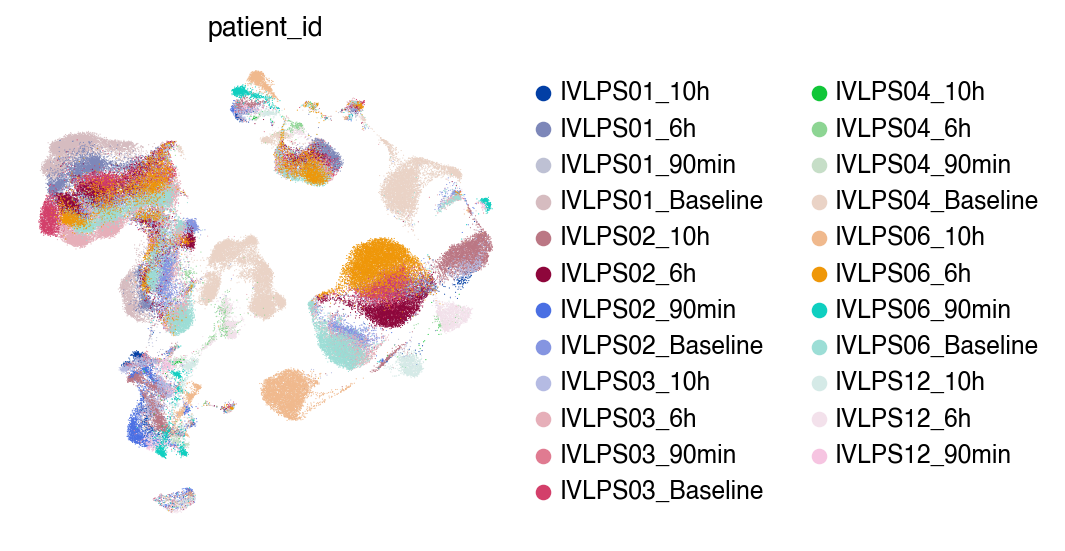

In [12]:
sc.pl.umap(
    combined_data,
    color='patient_id',
    frameon=False
    ,save='patient_id.svg'
)

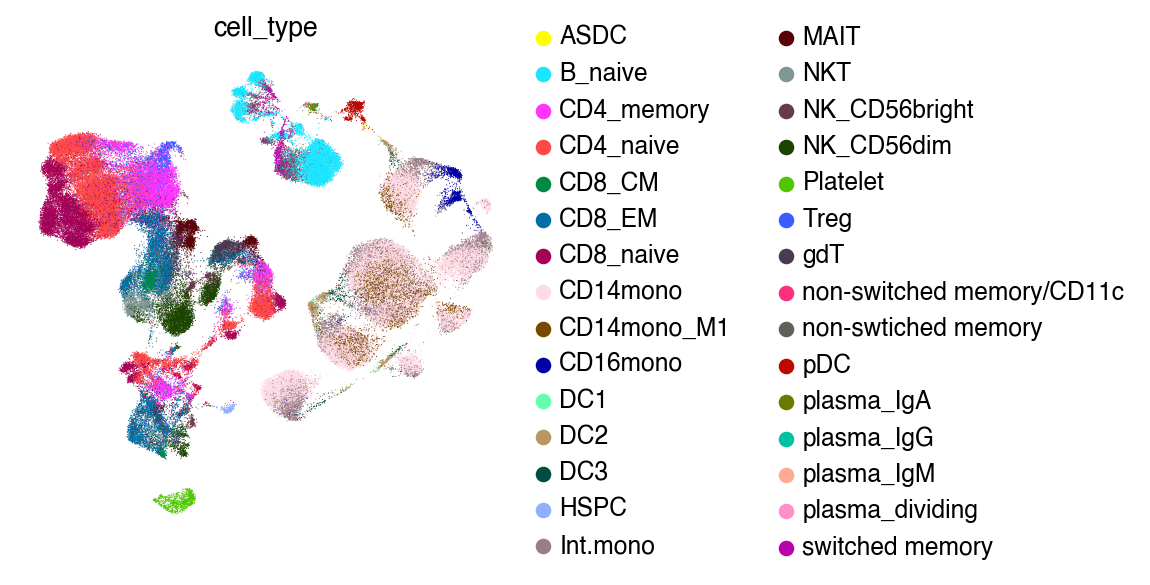

In [13]:
sc.pl.umap(
    combined_data,
    color='cell_type',
    frameon=False
    ,save='cell_type.svg'
)


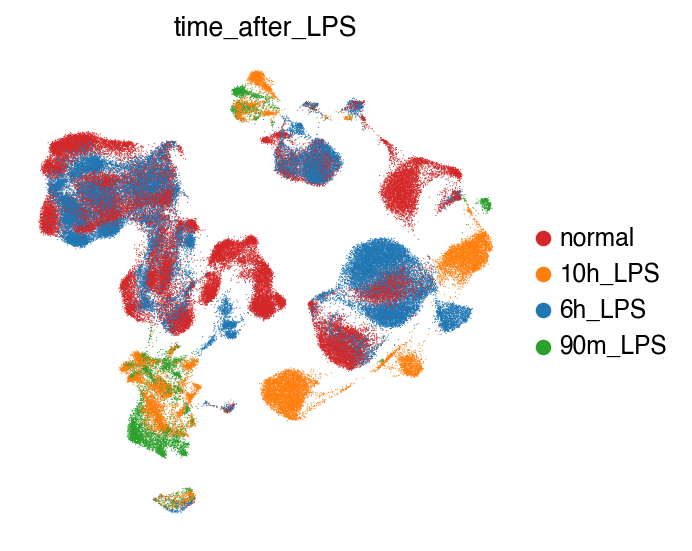

In [14]:
sc.pl.umap(
    combined_data,
    color='time_after_LPS',
    frameon=False,
    palette=palette, save='timepoints.svg'
)
